# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

## Q. Analytical Derivation

**Setup**

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}, \qquad y_k^- = H_k x_k^- + z_k
$$

with $x_{k-1}^+ \sim N(m_{k-1}, P_{k-1})$, process noise $w_{k-1}\sim N(0,\Sigma_p)$, measurement noise $z_k \sim N(0,\Sigma_m)$, and all noise terms mutually independent and independent of $x_{k-1}^+$.

---

### 1. Prediction step: distribution of $x_k^-$

Since $x_k^-$ is an affine combination of jointly Gaussian random vectors $x_{k-1}^+$ and $w_{k-1}$, it is itself Gaussian.

**Mean:**
$$
m_k^- = E[x_k^-] = A_{k-1}E[x_{k-1}^+] + G_{k-1}E[w_{k-1}] = A_{k-1}m_{k-1}
$$

**Covariance** (cross terms vanish since $x_{k-1}^+ \perp w_{k-1}$):
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
$$

$$
\boxed{x_k^- \sim N(m_k^-,\, P_k^-), \quad m_k^- = A_{k-1}m_{k-1}, \quad P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T}
$$

---

### 2. Distribution of $y_k^-$

$y_k^- = H_k x_k^- + z_k$ is an affine transform of Gaussians ($x_k^- \perp z_k$), hence Gaussian.

**Mean:**
$$
E[y_k^-] = H_k E[x_k^-] + E[z_k] = H_k m_k^-
$$

**Covariance:**
$$
\mathrm{Cov}(y_k^-) = H_k\,\mathrm{Cov}(x_k^-)\,H_k^T + \mathrm{Cov}(z_k) = H_k P_k^- H_k^T + \Sigma_m
$$

$$
\boxed{y_k^- \sim N(H_k m_k^-,\; H_k P_k^- H_k^T + \Sigma_m)}
$$

---

### 3. Joint distribution of $(x_k^-, y_k^-)$

Any linear combination of $x_k^-$ and $y_k^-$ is a linear combination of the original jointly Gaussian variables, so the pair is jointly Gaussian. We need the cross-covariance:

$$
\mathrm{Cov}(x_k^-, y_k^-) = \mathrm{Cov}(x_k^-, H_k x_k^- + z_k) = P_k^- H_k^T
$$

(since $x_k^- \perp z_k$), and by symmetry $\mathrm{Cov}(y_k^-,x_k^-) = H_k P_k^-$.

$$
\boxed{
\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim N\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},\; \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)
}
$$

---

### 4. Posterior $x_k^+ \triangleq (x_k^- \mid y_k^- = y_k^{obs})$

For jointly Gaussian $\begin{bmatrix} a \\ b \end{bmatrix} \sim N\left(\begin{bmatrix}\mu_a\\ \mu_b\end{bmatrix}, \begin{bmatrix}\Sigma_{aa} & \Sigma_{ab}\\ \Sigma_{ba} & \Sigma_{bb}\end{bmatrix}\right)$, the conditional $(a\mid b=b_0)$ is Gaussian with

$$
E[a\mid b_0] = \mu_a + \Sigma_{ab}\Sigma_{bb}^{-1}(b_0 - \mu_b), \qquad \mathrm{Cov}(a\mid b_0) = \Sigma_{aa} - \Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}
$$

Applying with $a = x_k^-$, $b = y_k^-$, using moments from Part 3, and defining the **Kalman gain**

$$
K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}
$$

we obtain:

$$
m_k = m_k^- + K_k(y_k^{obs} - H_k m_k^-)
$$

$$
P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-
$$

$$
\boxed{
x_k^+ \sim N(m_k, P_k), \quad K_k = P_k^- H_k^T(H_kP_k^-H_k^T + \Sigma_m)^{-1},\quad m_k = m_k^- + K_k(y_k^{obs}-H_km_k^-),\quad P_k=(I-K_kH_k)P_k^-
}
$$

---

### 5. $E[x_k^-\mid y_k^- = y_k^{obs}]$ and $\mathrm{Var}(x_k^-\mid y_k^- = y_k^{obs})$

By definition $x_k^+ \triangleq (x_k^-\mid y_k^- = y_k^{obs})$, so these are exactly the results of Part 4:

$$
\boxed{E[x_k^- \mid y_k^- = y_k^{obs}] = m_k = m_k^- + K_k\left(y_k^{obs} - H_k m_k^-\right)}
$$

$$
\boxed{\mathrm{Var}(x_k^- \mid y_k^- = y_k^{obs}) = P_k = (I - K_k H_k)P_k^-}
$$

**Interpretation:** the conditional mean is the prior prediction $m_k^-$ corrected by the innovation $(y_k^{obs} - H_k m_k^-)$ scaled by the Kalman gain — the optimal blend of model prediction and new measurement. The conditional covariance $P_k \preceq P_k^-$ confirms that conditioning on a new observation never increases uncertainty about the state.

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Q. 2D-Position Estimation — Part A

**State and measurement model**

$$
x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}, \qquad
y_k = \begin{bmatrix} p_x^{meas}(k) \\ p_y^{meas}(k) \end{bmatrix}
$$

We model the system as constant-velocity motion, where the only stochastic forcing is a **random acceleration** (white noise) acting independently on each axis:

$$
w_{k-1} = \begin{bmatrix} w_x \\ w_y \end{bmatrix} \sim N(0,\Sigma_p)
$$

i.e. the true continuous-time dynamics are $\ddot{p}_x = w_x$, $\ddot{p}_y = w_y$ (a "nearly constant velocity" model), discretized over a time step $\Delta t$.

---

### Derivation of $A$ and $G$

**Velocity update.** Treating $w_x$ as a constant impulsive acceleration over the interval $[k-1,k]$:

$$
v_x(k) = v_x(k-1) + \Delta t\, w_x, \qquad v_y(k) = v_y(k-1) + \Delta t\, w_y
$$

**Position update.** Integrating velocity over the interval (constant velocity $v_x(k-1)$ plus the contribution of the constant acceleration $w_x$ during $\Delta t$, i.e. $\int_0^{\Delta t}\!\!\int_0^{\tau} w_x \, ds\, d\tau = \tfrac{1}{2}\Delta t^2 w_x$):

$$
p_x(k) = p_x(k-1) + \Delta t\, v_x(k-1) + \tfrac{1}{2}\Delta t^2\, w_x
$$
$$
p_y(k) = p_y(k-1) + \Delta t\, v_y(k-1) + \tfrac{1}{2}\Delta t^2\, w_y
$$

**Collecting into matrix form.** Writing all four equations as $x_k = A\,x_{k-1}^+ + G\,w_{k-1}$:

$$
\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}
=
\underbrace{\begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}}_{A}
\begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}
+
\underbrace{\begin{bmatrix} \tfrac{1}{2}\Delta t^2 & 0 \\ 0 & \tfrac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}}_{G}
\begin{bmatrix} w_x \\ w_y \end{bmatrix}
$$

Reading off each block confirms:

$$
\boxed{
A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \qquad
G = \begin{bmatrix} \tfrac{1}{2}\Delta t^2 & 0 \\ 0 & \tfrac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}
}
$$

---

### Derivation of $H$

The measurement $y_k$ only observes the position components, so $H$ must select rows 1 and 2 (corresponding to $p_x$, $p_y$) and zero out the velocity rows:

$$
y_k = \begin{bmatrix} p_x^{meas}(k) \\ p_y^{meas}(k) \end{bmatrix}
=
\underbrace{\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}}_{H}
\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}
+ z_k
$$

since $p_x^{meas}(k) = 1\cdot p_x(k) + 0\cdot p_y(k) + 0\cdot v_x(k) + 0\cdot v_y(k) + z_{x}$, and similarly for $p_y^{meas}(k)$.

$$
\boxed{H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}}
$$

---

### Summary

$$
x_k^- = A x_{k-1}^+ + G w_{k-1}, \qquad y_k^- = H x_k^- + z_k
$$

with

$$
A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \qquad
H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}, \qquad
G = \begin{bmatrix} \tfrac{1}{2}\Delta t^2 & 0 \\ 0 & \tfrac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}
$$

as required. $\blacksquare$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

RMSE of raw GPS measurements : 6.984 m
RMSE of Kalman-filtered path : 3.726 m
Improvement                  : 46.6%

Plot saved to kalman_gps_demo.png


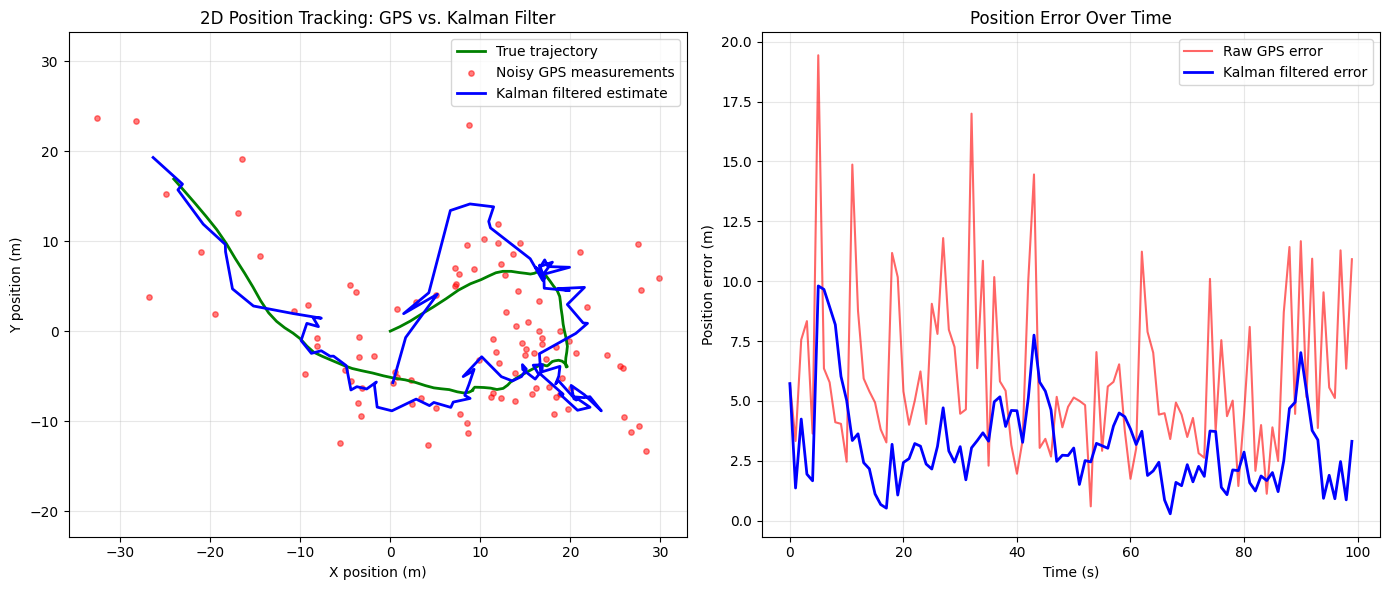

In [1]:
"""
2D Constant-Velocity Kalman Filter for Noisy GPS Position Tracking
====================================================================

State vector:   x_k = [p_x, p_y, v_x, v_y]^T
Measurement:    y_k = [p_x_meas, p_y_meas]^T

Model (from Part A):
    x_k^- = A x_{k-1}^+ + G w_{k-1},   w_{k-1} ~ N(0, Sigma_p)
    y_k^- = H x_k^-      + z_k,        z_k     ~ N(0, Sigma_m)

    A = [[1, 0, dt, 0],
         [0, 1, 0, dt],
         [0, 0, 1,  0],
         [0, 0, 0,  1]]

    H = [[1, 0, 0, 0],
         [0, 1, 0, 0]]

    G = [[dt^2/2,     0  ],
         [0,       dt^2/2],
         [dt,          0 ],
         [0,          dt]]
"""

import numpy as np
import matplotlib.pyplot as plt


class KalmanFilterGPS:
    """Constant-velocity Kalman filter for 2D GPS position tracking."""

    def __init__(self, dt, sigma_p, sigma_m, x0=None, P0=None):
        """
        Parameters
        ----------
        dt : float
            Time step between measurements (s).
        sigma_p : float
            Std. dev. of the process noise (acceleration), used to build Sigma_p.
        sigma_m : float
            Std. dev. of the GPS measurement noise (m), used to build Sigma_m.
        x0 : (4,) array_like, optional
            Initial state estimate [px, py, vx, vy]. Defaults to zeros.
        P0 : (4,4) array_like, optional
            Initial state covariance. Defaults to a large diagonal (uninformative prior).
        """
        self.dt = dt

        # State transition matrix A
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # Measurement matrix H (observe position only)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise input matrix G
        self.G = np.array([
            [dt**2 / 2, 0],
            [0, dt**2 / 2],
            [dt, 0],
            [0, dt]
        ])

        # Process noise covariance Sigma_p (acceleration noise, assumed isotropic)
        self.Sigma_p = (sigma_p ** 2) * np.eye(2)

        # Measurement noise covariance Sigma_m (GPS noise, assumed isotropic)
        self.Sigma_m = (sigma_m ** 2) * np.eye(2)

        # Initial state and covariance
        self.x = np.zeros(4) if x0 is None else np.asarray(x0, dtype=float)
        self.P = np.eye(4) * 1e3 if P0 is None else np.asarray(P0, dtype=float)

    def predict(self):
        """Time update (prediction) step."""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.G @ self.Sigma_p @ self.G.T
        return self.x, self.P

    def update(self, y_obs):
        """
        Measurement update (correction) step.

        Parameters
        ----------
        y_obs : (2,) array_like
            Observed GPS position [px_meas, py_meas].
        """
        y_obs = np.asarray(y_obs, dtype=float)

        # Innovation (residual)
        innovation = y_obs - self.H @ self.x

        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.Sigma_m

        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State and covariance update
        self.x = self.x + K @ innovation
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P

        return self.x, self.P

    def step(self, y_obs):
        """Convenience: predict then update in one call."""
        self.predict()
        return self.update(y_obs)


def filter_sequence(measurements, dt, sigma_p, sigma_m, x0=None, P0=None):
    """
    Run the Kalman filter over an entire sequence of GPS measurements.

    Parameters
    ----------
    measurements : (N, 2) array_like
        Sequence of noisy GPS position measurements.
    dt, sigma_p, sigma_m, x0, P0 : see KalmanFilterGPS.

    Returns
    -------
    filtered_states : (N, 4) ndarray
        Filtered state estimates [px, py, vx, vy] at each step.
    covariances : (N, 4, 4) ndarray
        Posterior covariance at each step.
    """
    measurements = np.asarray(measurements)
    N = measurements.shape[0]

    kf = KalmanFilterGPS(dt, sigma_p, sigma_m, x0=x0, P0=P0)

    filtered_states = np.zeros((N, 4))
    covariances = np.zeros((N, 4, 4))

    for k in range(N):
        x_est, P_est = kf.step(measurements[k])
        filtered_states[k] = x_est
        covariances[k] = P_est

    return filtered_states, covariances


# ----------------------------------------------------------------------
# Demonstration on synthetic noisy GPS data
# ----------------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)

    # --- Simulation parameters ---
    dt = 1.0           # 1 second between GPS fixes
    N = 100             # number of time steps
    true_sigma_p = 0.2  # true process (acceleration) noise std
    true_sigma_m = 5.0  # true GPS measurement noise std (meters)

    # --- Generate ground-truth trajectory (e.g. gentle curving path) ---
    true_states = np.zeros((N, 4))
    true_states[0] = [0, 0, 1.0, 0.5]  # start at origin, moving at (1,0.5) m/s

    A_true = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    G_true = np.array([
        [dt**2/2, 0],
        [0, dt**2/2],
        [dt, 0],
        [0, dt]
    ])

    for k in range(1, N):
        w = np.random.normal(0, true_sigma_p, size=2)
        true_states[k] = A_true @ true_states[k-1] + G_true @ w

    true_positions = true_states[:, :2]

    # --- Generate noisy GPS measurements ---
    measurement_noise = np.random.normal(0, true_sigma_m, size=(N, 2))
    gps_measurements = true_positions + measurement_noise

    # --- Run Kalman filter ---
    x0_init = np.array([gps_measurements[0, 0], gps_measurements[0, 1], 0, 0])
    P0_init = np.diag([true_sigma_m**2, true_sigma_m**2, 10, 10])

    filtered_states, covariances = filter_sequence(
        gps_measurements, dt,
        sigma_p=true_sigma_p, sigma_m=true_sigma_m,
        x0=x0_init, P0=P0_init
    )

    filtered_positions = filtered_states[:, :2]

    # --- Compute error metrics ---
    rmse_raw = np.sqrt(np.mean(np.sum((gps_measurements - true_positions)**2, axis=1)))
    rmse_filtered = np.sqrt(np.mean(np.sum((filtered_positions - true_positions)**2, axis=1)))

    print(f"RMSE of raw GPS measurements : {rmse_raw:.3f} m")
    print(f"RMSE of Kalman-filtered path : {rmse_filtered:.3f} m")
    print(f"Improvement                  : {100*(1 - rmse_filtered/rmse_raw):.1f}%")

    # --- Plot results ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Trajectory plot
    ax = axes[0]
    ax.plot(true_positions[:, 0], true_positions[:, 1], 'g-', linewidth=2, label='True trajectory')
    ax.scatter(gps_measurements[:, 0], gps_measurements[:, 1], c='red', s=15, alpha=0.5, label='Noisy GPS measurements')
    ax.plot(filtered_positions[:, 0], filtered_positions[:, 1], 'b-', linewidth=2, label='Kalman filtered estimate')
    ax.set_xlabel('X position (m)')
    ax.set_ylabel('Y position (m)')
    ax.set_title('2D Position Tracking: GPS vs. Kalman Filter')
    ax.legend()
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

    # Position error over time
    ax = axes[1]
    time = np.arange(N) * dt
    error_raw = np.linalg.norm(gps_measurements - true_positions, axis=1)
    error_filtered = np.linalg.norm(filtered_positions - true_positions, axis=1)
    ax.plot(time, error_raw, 'r-', alpha=0.6, label='Raw GPS error')
    ax.plot(time, error_filtered, 'b-', linewidth=2, label='Kalman filtered error')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position error (m)')
    ax.set_title('Position Error Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('kalman_gps_demo.png', dpi=150)
    print("\nPlot saved to kalman_gps_demo.png")
